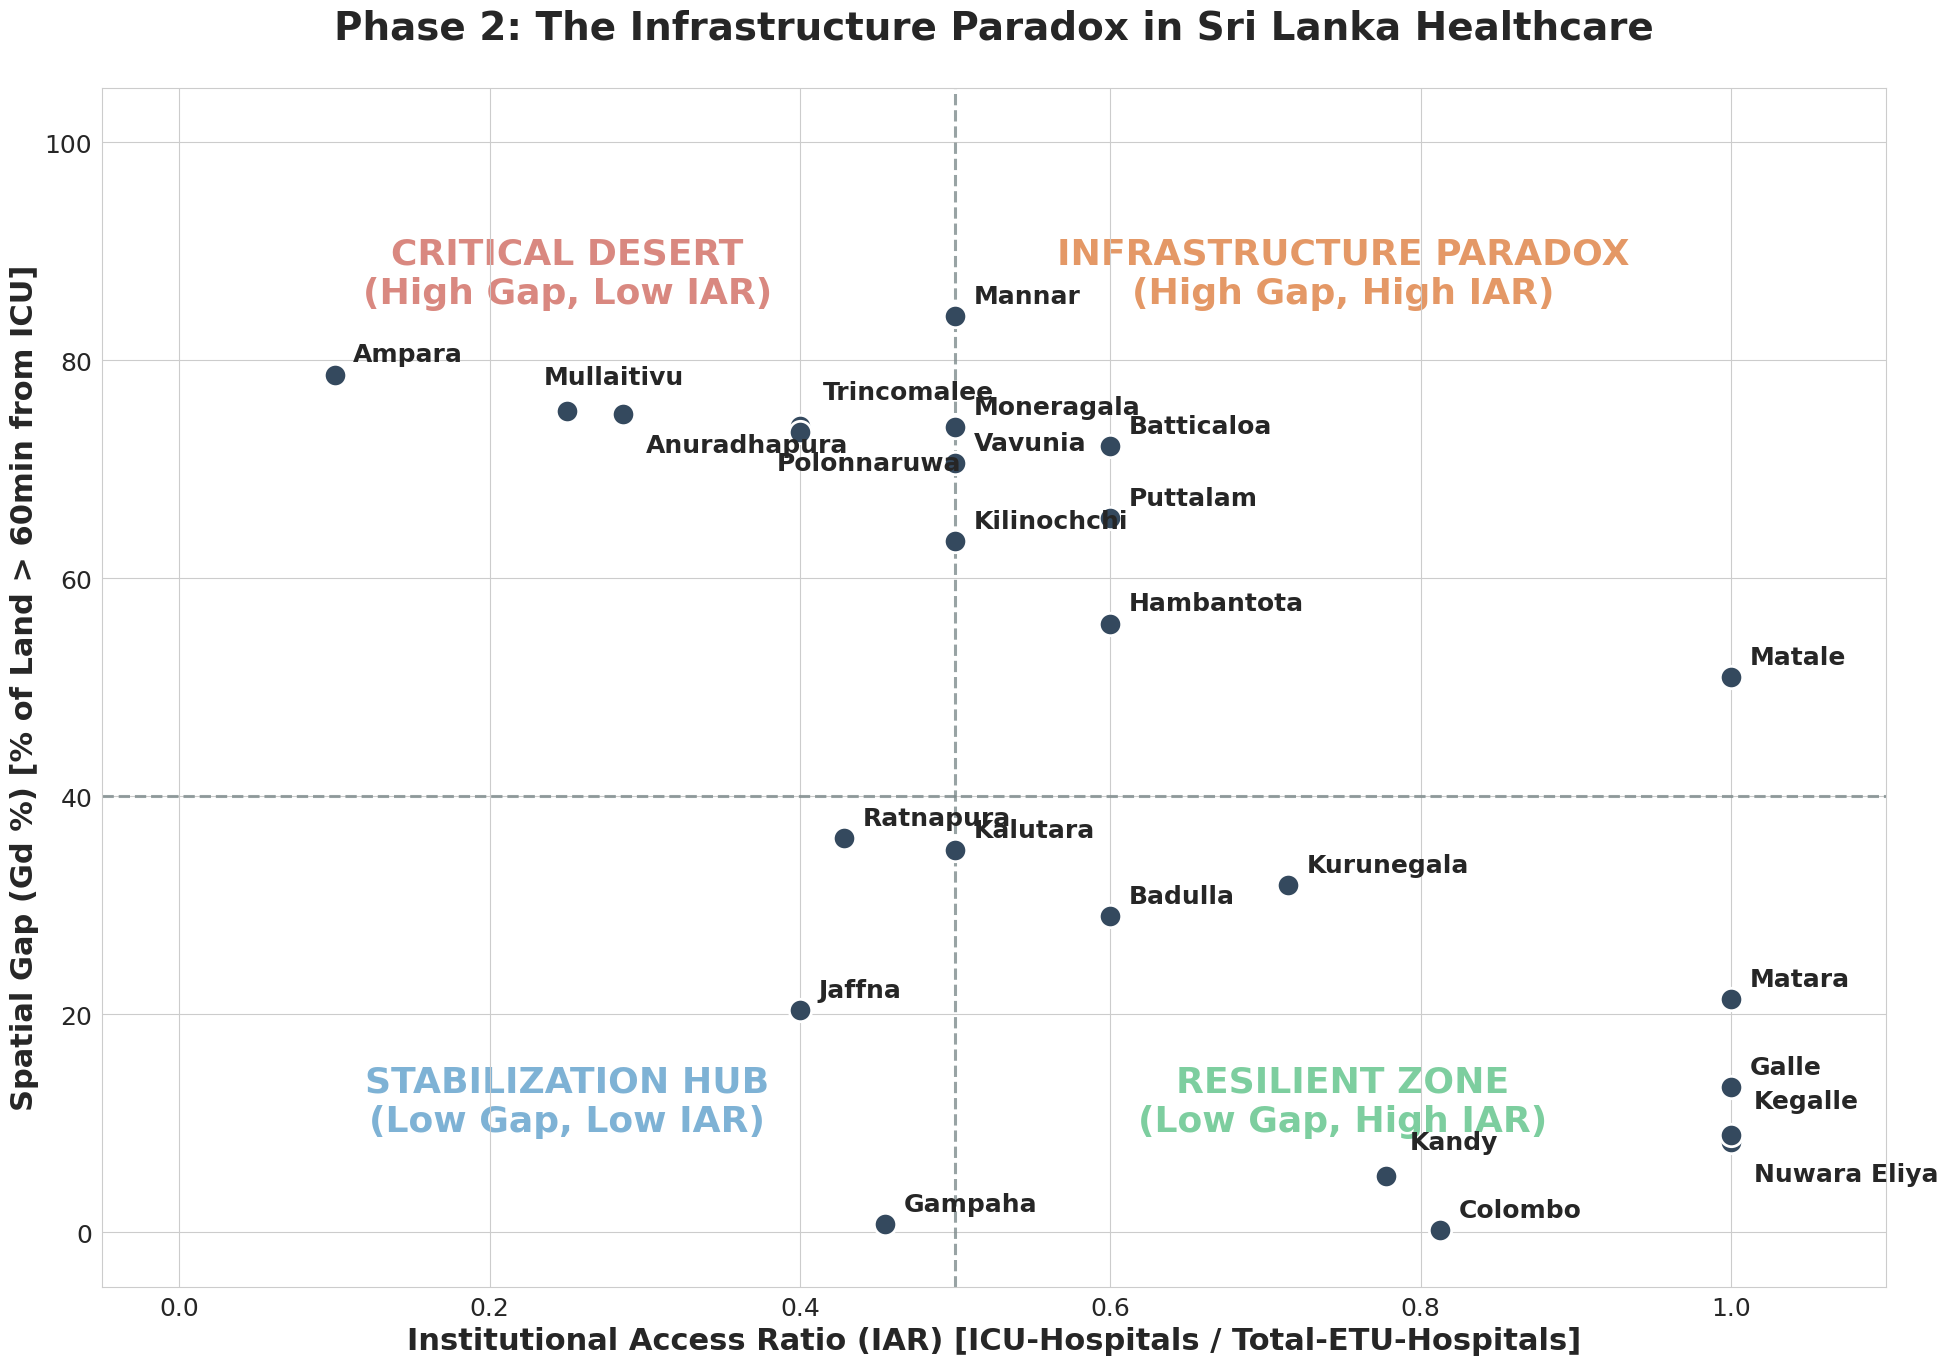

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your data
df = pd.read_csv('Research_Phase2_1.csv')

# 2. GLOBAL FONT SCALING (STRONGER)
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 28,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18
})

# 3. Set the style
plt.figure(figsize=(20, 14))  # bigger canvas
sns.set_style("whitegrid")

# 4. QUADRANT LABELS (VERY PROMINENT)
plt.text(0.25, 88, 'CRITICAL DESERT\n(High Gap, Low IAR)', color='#c0392b', fontsize=26,
         fontweight='black', alpha=0.6, ha='center', va='center', zorder=0)

plt.text(0.75, 88, 'INFRASTRUCTURE PARADOX\n(High Gap, High IAR)', color='#d35400', fontsize=26,
         fontweight='black', alpha=0.6, ha='center', va='center', zorder=0)

plt.text(0.25, 12, 'STABILIZATION HUB\n(Low Gap, Low IAR)', color='#2980b9', fontsize=26,
         fontweight='black', alpha=0.6, ha='center', va='center', zorder=0)

plt.text(0.75, 12, 'RESILIENT ZONE\n(Low Gap, High IAR)', color='#27ae60', fontsize=26,
         fontweight='black', alpha=0.6, ha='center', va='center', zorder=0)

# 5. Scatter Plot (bigger points)
plt.scatter(df['IAR'], df['Gd'], s=260, color='#34495e',
            edgecolor='white', linewidth=2, alpha=1, zorder=5)

# 6. District Labels (CLEARLY READABLE)
for i, row in df.iterrows():
    name = row['District']
    x = row['IAR']
    y = row['Gd']
    dx, dy = 0.012, 1.2

    if name == 'Mullaitivu': dx, dy = -0.015, 2.5
    if name == 'Anuradhapura': dx, dy = 0.015, -3.5
    if name == 'Trincomalee': dx, dy = 0.015, 2.5
    if name == 'Polonnaruwa': dx, dy = -0.015, -3.5
    if name == 'Kegalle': dx, dy = 0.015, 2.5
    if name == 'Nuwara Eliya': dx, dy = 0.015, -3.5
    if name == 'Kandy': dx, dy = 0.015, 2.5

    plt.text(x + dx, y + dy, name, fontsize=18, fontweight='bold', zorder=10)

# 7. Threshold lines (clearer)
plt.axhline(y=40, color='#7f8c8d', linestyle='--', linewidth=2.2, alpha=0.8, zorder=1)
plt.axvline(x=0.5, color='#7f8c8d', linestyle='--', linewidth=2.2, alpha=0.8, zorder=1)

# 8. Final Axes Formatting
plt.title('Phase 2: The Infrastructure Paradox in Sri Lanka Healthcare', pad=35, fontweight='bold')
plt.xlabel('Institutional Access Ratio (IAR) [ICU-Hospitals / Total-ETU-Hospitals]', fontweight='bold')
plt.ylabel('Spatial Gap (Gd %) [% of Land > 60min from ICU]', fontweight='bold')

plt.xlim(-0.05, 1.1)
plt.ylim(-5, 105)

plt.tight_layout()

# 9. EXPORT (ULTRA CLEAR)
plt.savefig('Final_Perfect_Phase2_Plot_V2.png', dpi=800)

plt.show()


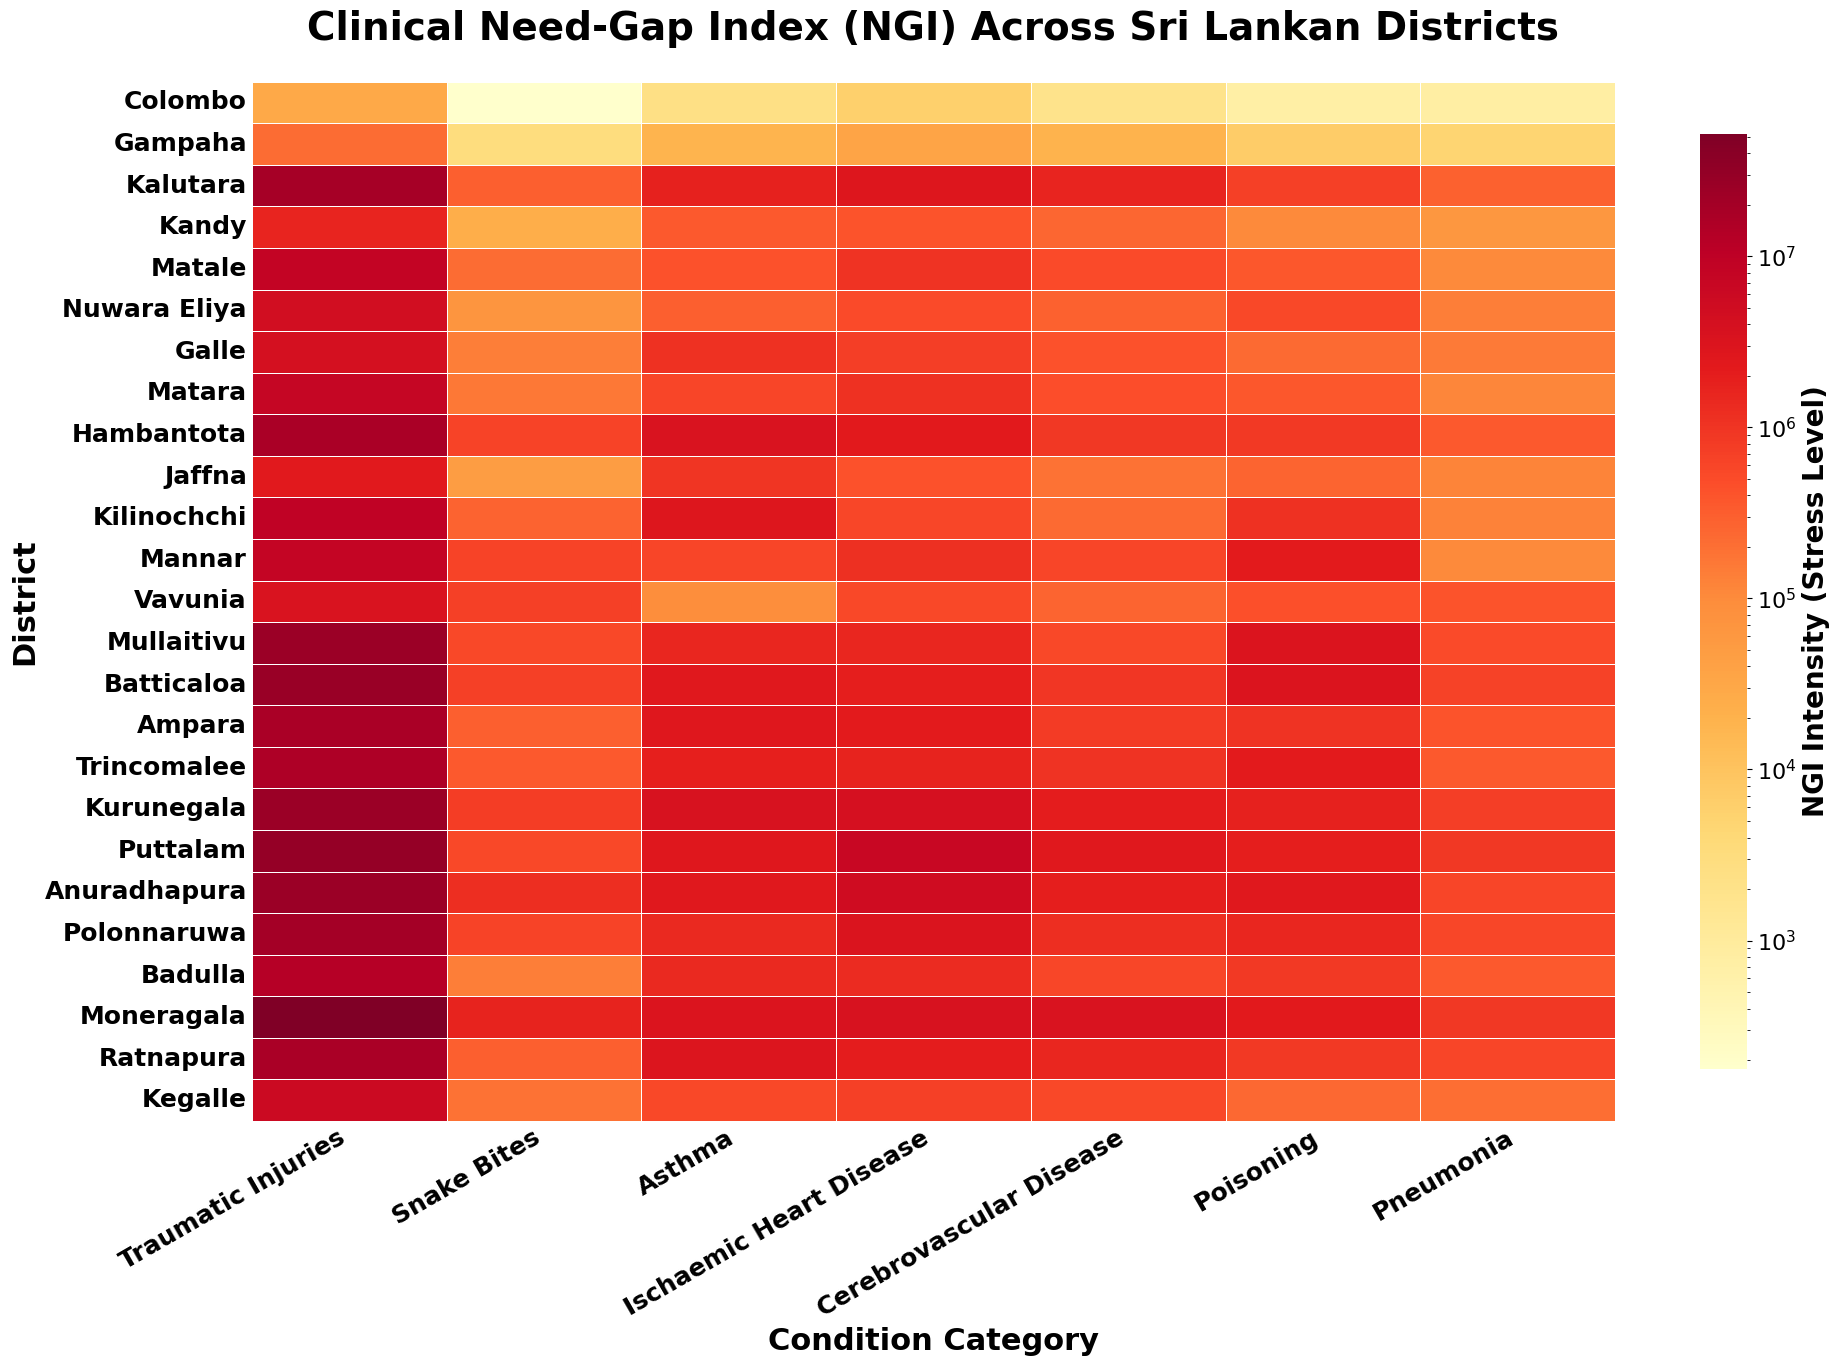

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# 1. Load your updated data
df = pd.read_csv('Phase3_Research.csv')

# Mapping for clinical names
rename_map = {
    'NGI_Trauma': 'Traumatic Injuries',
    'NGI_Snake_Bites': 'Snake Bites',
    'NGI_Asthma': 'Asthma',
    'NGI_IHD': 'Ischaemic Heart Disease',
    'NGI_CV': 'Cerebrovascular Disease',
    'NGI_Poisoning': 'Poisoning',
    'NGI_Pneumonia': 'Pneumonia'
}

# Prepare data
heatmap_data = df.set_index('District')[list(rename_map.keys())]
heatmap_data.rename(columns=rename_map, inplace=True)

# 2. Fonts
plt.rcParams.update({
    'font.size': 18,
    'axes.titlesize': 28,
    'axes.labelsize': 22
})

# 3. Figure
plt.figure(figsize=(20, 14))

# 4. Heatmap
ax = sns.heatmap(
    heatmap_data,
    annot=False,
    cmap='YlOrRd',
    norm=LogNorm(),
    linewidths=0.6,
    linecolor='white',
    cbar_kws={'label': 'NGI Intensity (Stress Level)', 'shrink': 0.9}
)

# 5. 🔥 X labels (with white background box)
xticks = ax.get_xticklabels()
ax.set_xticklabels(
    xticks,
    rotation=30,
    ha='right',
    fontsize=18,
    fontweight='bold',
    color='black'
)

for label in ax.get_xticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2))

# 6. 🔥 Y labels (with white background box)
yticks = ax.get_yticklabels()
ax.set_yticklabels(
    yticks,
    rotation=0,
    fontsize=18,
    fontweight='bold',
    color='black'
)

for label in ax.get_yticklabels():
    label.set_bbox(dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2))

# 7. Remove tick marks
ax.tick_params(axis='both', length=0)

# 8. Colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=16, colors='black')
cbar.set_label('NGI Intensity (Stress Level)', fontsize=20, fontweight='bold')

# 9. Titles
plt.title('Clinical Need-Gap Index (NGI) Across Sri Lankan Districts',
          fontweight='bold', pad=30)

plt.ylabel('District', fontweight='bold')
plt.xlabel('Condition Category', fontweight='bold')

# 10. Layout
plt.tight_layout()

# 11. Export
plt.savefig('Step1_NGI_Heatmap_New.png', dpi=800)

plt.show()


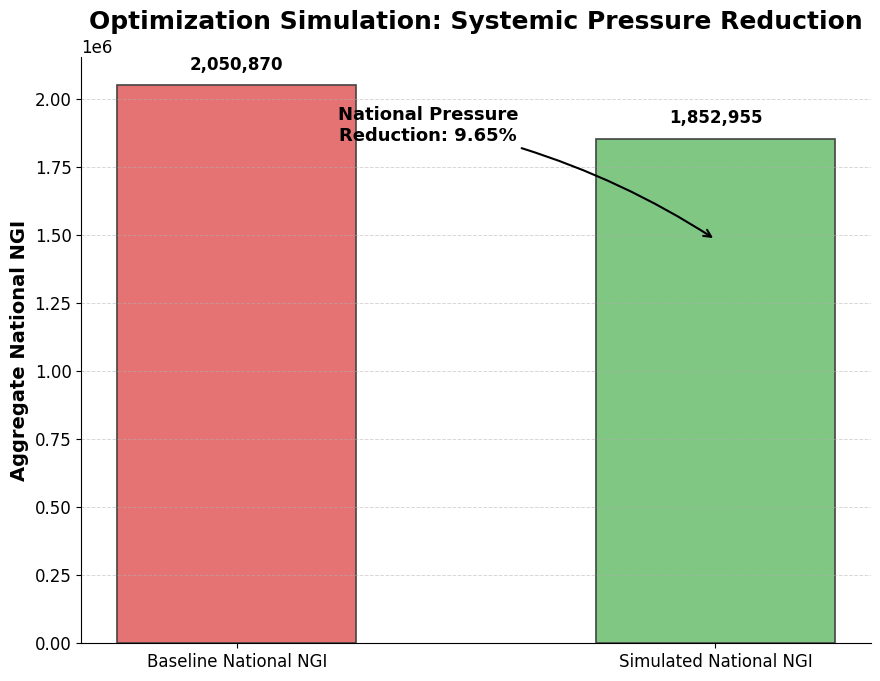

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('Phase4_Final_Policy_Results.csv')

# 2. SIMULATION LOGIC
REDUCTION_FACTOR = 0.25
red_mask = df['Policy_Category'] == 'Red: Critical Exclusion'
red_districts = df[red_mask].copy()
red_districts['Simulated_NGI'] = red_districts['General_NGI'] * (1 - REDUCTION_FACTOR)

# 3. IMPACT CALCULATION
total_baseline_ngi = df['General_NGI'].sum()
total_simulated_ngi = (df[~red_mask]['General_NGI'].sum() + red_districts['Simulated_NGI'].sum())
national_reduction_pct = ((total_baseline_ngi - total_simulated_ngi) / total_baseline_ngi) * 100

# 4. SOFT PALETTE (kept same)
SOFT_INTERMEDIATE = ['#E57373', '#81C784']

# 🔥 GLOBAL FONT BOOST
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

plt.figure(figsize=(9, 7))  # slightly bigger

labels = ['Baseline National NGI', 'Simulated National NGI']
values = [total_baseline_ngi, total_simulated_ngi]

# 🔥 Stronger bars
bars = plt.bar(
    labels,
    values,
    color=SOFT_INTERMEDIATE,
    width=0.5,
    edgecolor='#444444',   # darker edge
    linewidth=1.2
)

# --- CLEAN LAYOUT ---
plt.title('Optimization Simulation: Systemic Pressure Reduction',
          fontweight='bold', pad=20)

plt.ylabel('Aggregate National NGI', fontweight='bold')

# Style adjustments
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.5)

# 🔥 Data labels (more visible)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + (total_baseline_ngi * 0.02),
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='black'   # 🔥 darker
    )

# 🔥 Stronger annotation
plt.annotate(
    f'National Pressure\nReduction: {national_reduction_pct:.2f}%',
    xy=(1, total_simulated_ngi * 0.8),
    xytext=(0.4, total_baseline_ngi * 0.9),
    arrowprops=dict(
        arrowstyle="->",
        color="black",        # 🔥 darker arrow
        lw=1.5,
        connectionstyle="arc3,rad=-0.1"
    ),
    ha='center',
    fontsize=13,
    fontweight='bold',
    color='black'          # 🔥 stronger green text
)

plt.tight_layout()

# 🔥 HIGH QUALITY EXPORT
plt.savefig('Phase4_Simulation_Impact_Soft_Intermediate.png', dpi=600)

plt.show()


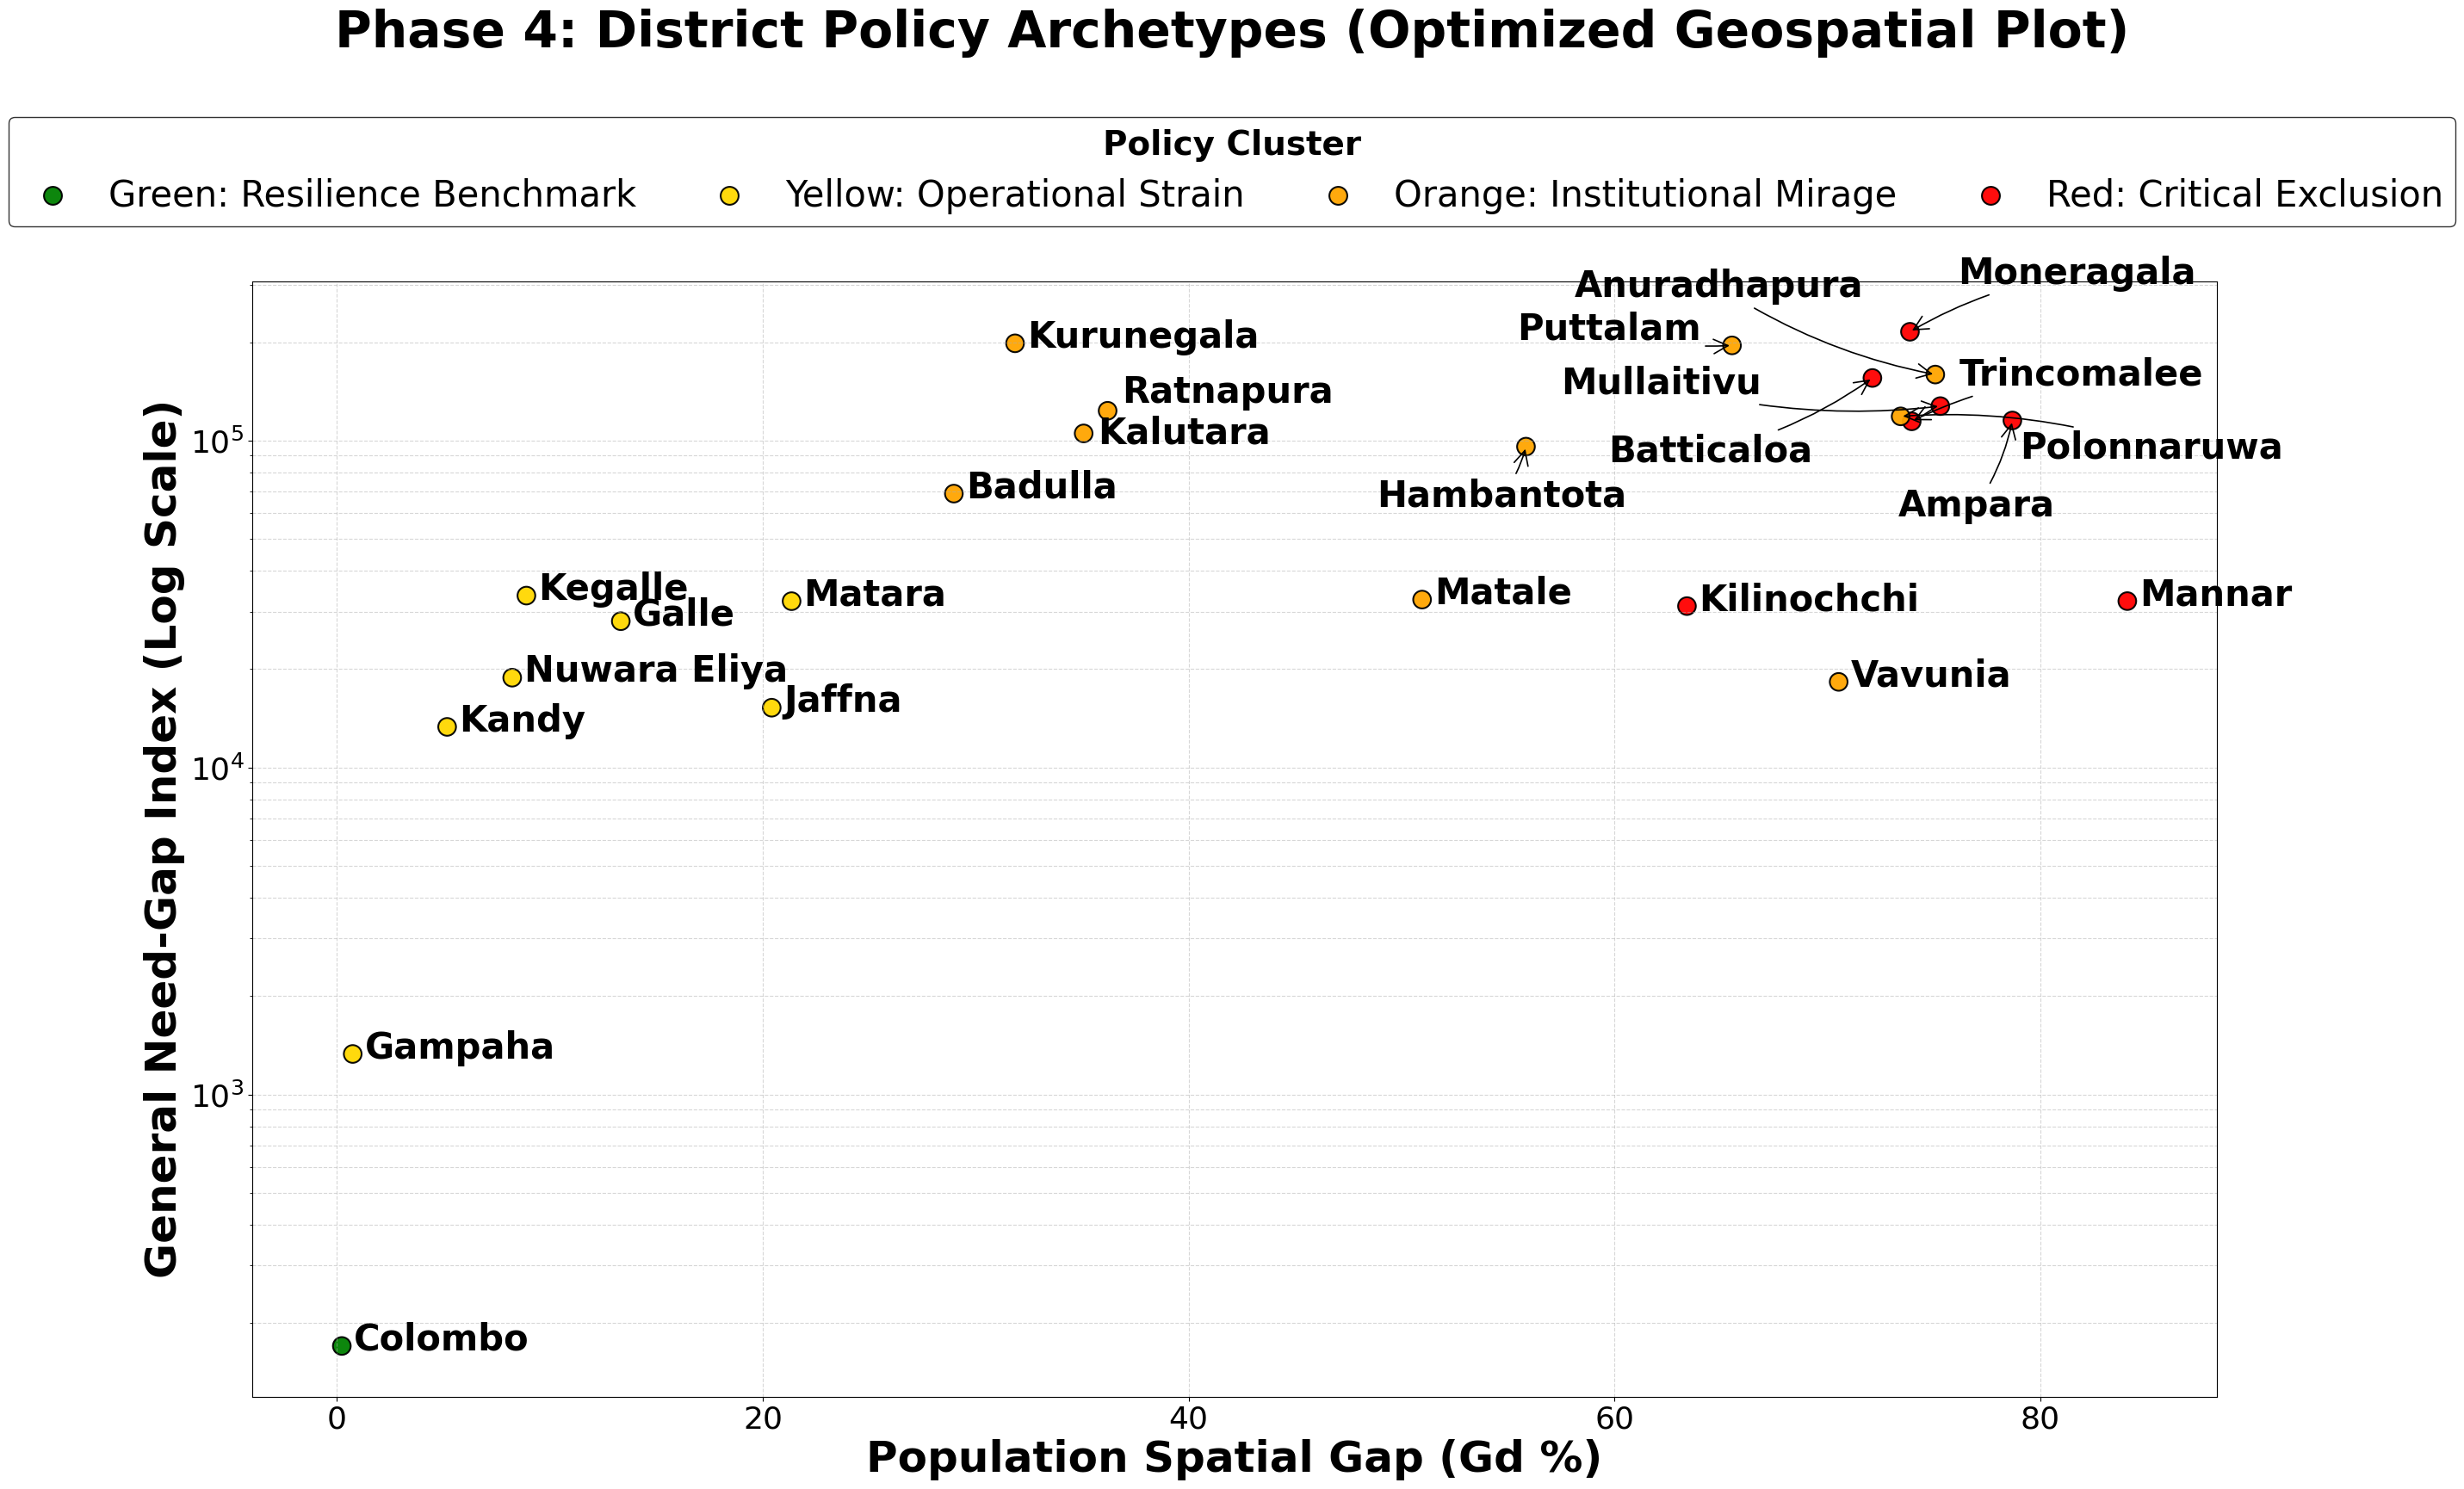

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. LOAD DATA
df = pd.read_csv('Phase4_Check_1.csv')

# 2. FEATURE ENGINEERING & CLUSTERING
df['TCR'] = (df['Hex_Covered_1hr'] * 0.737 / df['District_Area_km2']) * 100
df['TCR'] = df['TCR'].clip(upper=100)

features = ['Gd', 'General_NGI', 'Lethality Ratio', 'TCR', 'Average_Resource_Score']

X_scaled = StandardScaler().fit_transform(df[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 3. POLICY CATEGORIES
cluster_means = df.groupby('Cluster_ID')[features].mean()
cluster_means['Rank'] = cluster_means['Gd'] + (cluster_means['Lethality Ratio'] * 100)

sorted_indices = cluster_means.sort_values('Rank', ascending=False).index.tolist()

policy_labels = {
    sorted_indices[0]: 'Red: Critical Exclusion',
    sorted_indices[1]: 'Orange: Institutional Mirage',
    sorted_indices[2]: 'Yellow: Operational Strain',
    sorted_indices[3]: 'Green: Resilience Benchmark'
}

df['Policy_Category'] = df['Cluster_ID'].map(policy_labels)

# ---------------- VISUALIZATION ---------------- #

plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 40,
    'axes.labelsize': 32,
    'xtick.labelsize': 26,
    'ytick.labelsize': 26,
    'legend.fontsize': 22
})

fig, ax = plt.subplots(figsize=(26, 18))

# Color palette
palette = {
    'Red: Critical Exclusion': 'red',
    'Orange: Institutional Mirage': 'orange',
    'Yellow: Operational Strain': 'gold',
    'Green: Resilience Benchmark': 'green'
}

# Scatter plot
sns.scatterplot(
    data=df,
    x='Gd',
    y='General_NGI',
    hue='Policy_Category',
    palette=palette,
    s=220,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.95,
    ax=ax
)

# -------- ANNOTATIONS -------- #
for i in range(df.shape[0]):
    district = df['District'].iloc[i]
    x = df.Gd.iloc[i]
    y = df.General_NGI.iloc[i]

    ha, va = 'left', 'bottom'
    xytext = (10, 5)
    use_arrow = False

    if district == 'Anuradhapura':
        xytext, ha, use_arrow = (-60, 65), 'right', True
    elif district == 'Polonnaruwa':
        xytext, ha, use_arrow = (100, -35), 'left', True
    elif district == 'Trincomalee':
        xytext, ha, use_arrow = (40, 30), 'left', True
    elif district == 'Batticaloa':
        xytext, ha, use_arrow = (-50, -70), 'right', True
    elif district == 'Moneragala':
        xytext, ha, use_arrow = (40, 40), 'left', True
    elif district == 'Mullaitivu':
        xytext, ha, use_arrow = (-150, 10), 'right', True   # 🔥 shifted left
    elif district == 'Puttalam':
        xytext, ha, use_arrow = (-180, 5), 'left', True    # ✅ unchanged
    elif district == 'Kalutara':
        xytext, ha = (12, 0), 'left'
    elif district == 'Ratnapura':
        xytext, ha = (12, 15), 'left'
    elif district == 'Hambantota':
        xytext, ha, use_arrow = (-20, -50), 'center', True
    elif district == 'Ampara':
        xytext, ha, use_arrow = (-30, -80), 'center', True   # 🔥 moved downward

    if use_arrow:
        ax.annotate(
            district,
            xy=(x, y),
            xytext=xytext,
            textcoords='offset points',
            ha=ha,
            fontweight='bold',
            fontsize=30,
            color='black',
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle='arc3,rad=0.1',
                color='black',
                linewidth=1.2
            )
        )
    else:
        ax.annotate(
            district,
            xy=(x, y),
            xytext=xytext,
            textcoords='offset points',
            ha=ha,
            va='center',
            fontweight='bold',
            fontsize=30,
            color='black'
        )

# Axis scaling
ax.set_yscale('log')

# Labels
ax.set_xlabel('Population Spatial Gap (Gd %)', fontweight='bold', fontsize=36)
ax.set_ylabel('General Need-Gap Index (Log Scale)', fontweight='bold', fontsize=36)

# Title
fig.suptitle(
    'Phase 4: District Policy Archetypes (Optimized Geospatial Plot)',
    fontsize=42,
    fontweight='bold',
    y=0.97
)

# Legend
handles, labels = ax.get_legend_handles_labels()
legend = fig.legend(
    handles,
    labels,
    title='Policy Cluster',
    title_fontsize=28,
    fontsize=26,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.91),
    ncol=4,
    frameon=True,
    edgecolor='black'
)

# Bold legend text
for text in legend.get_texts():
    legend.get_title().set_fontweight('bold')
    text.set_fontsize(30)   # 🔥 increase as you like (e.g., 30–32)


# Increase legend marker size
for handle in legend.legend_handles:
    try:
        handle.set_sizes([400])
    except:
        try:
            handle.set_markersize(15)
        except:
            pass

# Remove duplicate legend
ax.legend_.remove()

# Grid
ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.5)

# Layout spacing
plt.tight_layout(rect=[0, 0, 1, 0.88])

# Save
plt.savefig('Phase4_Policy_Archetypes.png', dpi=800)

plt.show()
